In [1]:
# =============================================================================
# 带有实时绘图、每10个Epoch打印Loss与梯度、并在结束后进行最终评估的消融实验代码
# =============================================================================

import os
import sys
import json
import itertools
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from scipy import linalg

from IPython import display
import matplotlib.pyplot as plt

# =============================================================================
# 全局设置与数据加载
# =============================================================================
SEED         = 67890
BATCH_SIZE   = 100
EPOCHS       = 200
LR           = 2e-4
SAVE_DIR_ROOT = "D:/PRE2025/resultsablation/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SAVE_DIR_ROOT, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

def make_train_loader():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
    train_dataset = MNIST(root="./data/", train=True, download=True, transform=transform)
    return DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# =============================================================================
# 模型定义 (Vsig, Generator, Discriminator, SimpleCNN, FeatureExtractor)
# =============================================================================
class Vsig(nn.Module):
    def __init__(self, init_sigma=0.2, learnable=True):
        super().__init__()
        t = torch.tensor(init_sigma, dtype=torch.float32)
        if learnable:
            self.sigma = nn.Parameter(t)
        else:
            self.register_buffer("sigma", t)
            
    def forward(self, x):
        # 保护 1: 防止 learnable sigma 变成负数或极度接近 0
        # 保证分母至少是 1e-4，防止除零爆炸和正负号翻转
        safe_sigma = torch.clamp(self.sigma, min=1e-4)
        
        # 保护 2: 强烈建议改用 PyTorch 原生的 sigmoid 替代手动 exp
        # torch.sigmoid 底层对极大极小值有截断优化，不会溢出产生 NaN
        out = torch.sigmoid(x / safe_sigma)
        
        # 保护 3: 终极保护伞，防止输出绝对的 0.0 或 1.0 导致 BCELoss 中的 log(0) 爆炸
        out = torch.clamp(out, min=1e-7, max=1.0 - 1e-7)
        
        return out

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),  nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),  nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784), nn.Tanh(),
        )
    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, final_activation="sigmoid", dropout_rate=0.3, instance_noise_std=0.0):
        super().__init__()
        self.instance_noise_std = float(instance_noise_std)
        if final_activation == "sigmoid":
            act = nn.Sigmoid()
        elif isinstance(final_activation, nn.Module):
            act = final_activation
        else:
            raise ValueError(f"bad final_activation: {final_activation}")

        self.model = nn.Sequential(
            nn.Linear(784, 1024), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(1024, 512), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(512, 256),  nn.LeakyReLU(0.2, inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(256, 1),    act,
        )
    def forward(self, x):
        x = x.view(x.size(0), 784)
        if self.instance_noise_std > 0 and self.training:
            x = x + self.instance_noise_std * torch.randn_like(x)
        out = self.model(x)
        return out.view(-1, 1)

# 指标评估所需的 CNN 和特征提取器
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(128 * 3 * 3, 128)
        self.fc2   = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# =============================================================================
# 辅助函数 (评估、指标计算)
# =============================================================================
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real_feat, fake_feat):
    mu1, sigma1 = real_feat.mean(0), np.cov(real_feat.T)
    mu2, sigma2 = fake_feat.mean(0), np.cov(fake_feat.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0.0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

# =============================================================================
# 单变体训练函数 (每 10 Epoch 打印 Loss 和梯度)
# =============================================================================
def train_variant(name, *, final_activation="sigmoid", dropout_rate=0.3,
                  instance_noise_std=0.0, label_smoothing=0.0):
    save_dir = os.path.join(SAVE_DIR_ROOT, name)
    os.makedirs(save_dir, exist_ok=True)

    # 重置随机数, 每个变体从完全相同的初始化和 minibatch 顺序开始
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    train_loader = make_train_loader()

    discriminator = Discriminator(final_activation, dropout_rate, instance_noise_std).to(DEVICE)
    generator = Generator().to(DEVICE)
    criterion = nn.BCELoss()
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LR)
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=LR)

    sigma_module = final_activation if isinstance(final_activation, Vsig) else None
    epoch_d_loss, epoch_g_loss, epoch_generator_grad_norm, epoch_sigma = [], [], [], []

    fa_name = type(final_activation).__name__ if isinstance(final_activation, nn.Module) else final_activation
    print(f"\n>>> 开始变体实验: {name}")
    print(f"    config: final_activation={fa_name}, dropout={dropout_rate}, "
          f"instance_noise={instance_noise_std}, label_smoothing={label_smoothing}, device={DEVICE}")
    print(f"{'Epoch':<8} | {'D Loss':<10} | {'G Loss':<10} | {'Grad Norm^2':<12} | {'Sigma':<8}")
    print("-" * 65)

    # 实时绘图句柄 (在循环内刷新, 不要提前 close)
    test_noise = torch.randn(16, 100).to(DEVICE)
    fig, ax = plt.subplots(4, 4, figsize=(4, 4))
    for i, j in itertools.product(range(4), range(4)): ax[i, j].axis('off')
    dh = display.display(fig, display_id=True)

    for epoch in range(EPOCHS):
        batch_d_loss, batch_g_loss, batch_grad_norm = [], [], []

        for n, (real_imgs, _) in enumerate(train_loader):
            real_imgs = real_imgs.to(DEVICE)
            bsz = real_imgs.size(0)
            real_labels = torch.full((bsz, 1), 1.0 - label_smoothing, device=DEVICE)
            fake_labels = torch.zeros(bsz, 1, device=DEVICE)

            # D step
            z = torch.randn(bsz, 100, device=DEVICE)
            fake_imgs = generator(z)
            discriminator.zero_grad()
            d_loss = criterion(discriminator(real_imgs), real_labels) + \
                     criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # G step (non-saturating: target = 1)
            z = torch.randn(bsz, 100, device=DEVICE)
            fake_imgs = generator(z)
            generator.zero_grad()
            g_loss = criterion(discriminator(fake_imgs), torch.ones(bsz, 1, device=DEVICE))
            g_loss.backward()

            # 记录梯度范数平方 (与原代码一致)
            total_norm = 0.0
            for p in generator.parameters():
                if p.grad is not None: total_norm += p.grad.data.norm(2).item() ** 2
            batch_grad_norm.append(total_norm)
            g_optimizer.step()

            batch_d_loss.append(d_loss.item())
            batch_g_loss.append(g_loss.item())

            # 刷新图像 (每20个epoch显示一次)
            if (n + 1) % 500 == 0 and epoch % 20 == 0:
                test_imgs = generator(test_noise).detach().cpu()
                for k in range(16):
                    i, j = k // 4, k % 4
                    ax[i, j].cla(); ax[i, j].axis('off')
                    ax[i, j].imshow(1 - test_imgs[k].view(28, 28), cmap='gray')
                dh.update(fig)
                fig.savefig(os.path.join(save_dir, f"epoch_{epoch}.png"))

        # 记录 Epoch 平均数据
        epoch_d_loss.append(float(np.mean(batch_d_loss)))
        epoch_g_loss.append(float(np.mean(batch_g_loss)))
        epoch_generator_grad_norm.append(float(np.mean(batch_grad_norm)))
        cur_sigma = float(sigma_module.sigma.detach().cpu().item()) if sigma_module else 1.0
        epoch_sigma.append(cur_sigma)

        # 每 10 个 Epoch 打印一次文字 Log (含首个 epoch)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{epoch+1:<8d} | {epoch_d_loss[-1]:<10.4f} | {epoch_g_loss[-1]:<10.4f} | "
                  f"{epoch_generator_grad_norm[-1]:<12.6f} | {cur_sigma:<8.4f}")

    plt.close(fig)   # 训练完再 close 实时预览窗口

    # ===== 训练结束，保存数据 =====
    np.save(os.path.join(save_dir, "epoch_d_loss.npy"),    np.array(epoch_d_loss))
    np.save(os.path.join(save_dir, "epoch_g_loss.npy"),    np.array(epoch_g_loss))
    np.save(os.path.join(save_dir, "epoch_grad_norm.npy"), np.array(epoch_generator_grad_norm))
    np.save(os.path.join(save_dir, "epoch_sigma.npy"),     np.array(epoch_sigma))

    # 保存模型权重, 便于事后补做可视化或补跑评估
    torch.save(generator.state_dict(),     os.path.join(save_dir, "generator.pt"))
    torch.save(discriminator.state_dict(), os.path.join(save_dir, "discriminator.pt"))

    # ===== 最终 4x4 可视化 + 1000 张评估样本 =====
    generator.eval()
    with torch.no_grad():
        final_imgs_16 = generator(torch.randn(16, 100, device=DEVICE)).cpu().view(16, 28, 28)
    fig_f, axes = plt.subplots(4, 4, figsize=(6, 6))
    for k in range(16):
        axes[k//4, k%4].imshow(1 - final_imgs_16[k], cmap="gray")
        axes[k//4, k%4].axis("off")
    fig_f.suptitle(name)
    fig_f.tight_layout()
    fig_f.savefig(os.path.join(save_dir, "final_generated.png"), dpi=300)
    fig_f.savefig(os.path.join(save_dir, "final_generated.eps"), dpi=300)
    plt.close(fig_f)

    # 保存 1000 个生成样本供后续 IS/FID 重算或 histogram 复用
    with torch.no_grad():
        samples_1000 = generator(torch.randn(1000, 100, device=DEVICE)).cpu().numpy()
        samples_1000 = samples_1000.reshape(-1, 28, 28).astype(np.float32)
    np.save(os.path.join(save_dir, "samples_1000.npy"), samples_1000)

    # ===== 最终指标评估 =====
    print(f"  [{name}] 训练完成，正在进行最终指标评估...")
    eval_classifier = SimpleCNN().to(DEVICE)
    c_opt = torch.optim.Adam(eval_classifier.parameters(), lr=1e-3)
    eval_classifier.train()
    for _ in range(2):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            c_opt.zero_grad()
            F.cross_entropy(eval_classifier(x), y).backward()
            c_opt.step()

    eval_feat_ext = FeatureExtractor().to(DEVICE)
    generator.eval()
    with torch.no_grad():
        fake_ims = generator(torch.randn(1000, 100, device=DEVICE)).view(-1, 1, 28, 28)
        fake_feat = eval_feat_ext(fake_ims).cpu().numpy()
        real_ims = []
        for imgs, _ in train_loader:
            real_ims.append(imgs)
            if sum(x.size(0) for x in real_ims) >= 1000: break
        real_feat = eval_feat_ext(torch.cat(real_ims, 0)[:1000].to(DEVICE)).cpu().numpy()

    is_m, is_s = calculate_inception_score(fake_ims, eval_classifier)
    fid_v = calculate_fid(real_feat, fake_feat)
    modes, kl_v, counts = calculate_mode_score(fake_ims, eval_classifier)

    results = {
        "IS":            [float(is_m), float(is_s)],
        "FID":           float(fid_v),
        "Modes":         int(modes),
        "KL":            float(kl_v),
        "class_counts":  {int(k): int(v) for k, v in dict(counts).items()},
        "config": {
            "name":               name,
            "final_activation":   fa_name,
            "dropout_rate":       dropout_rate,
            "instance_noise_std": instance_noise_std,
            "label_smoothing":    label_smoothing,
            "final_sigma":        cur_sigma,
            "final_grad_norm_sq": epoch_generator_grad_norm[-1],
        },
    }
    with open(os.path.join(save_dir, "results.json"), "w") as f:
        json.dump(results, f, indent=2)

    print(f"  指标结果: IS={is_m:.4f}±{is_s:.4f}, FID={fid_v:.4f}, "
          f"Mode={modes}/10, KL={kl_v:.4f}")
    print(f"  class_counts={dict(counts)}")
    print(f"  final_sigma={cur_sigma:.4f}, final_grad_sq={epoch_generator_grad_norm[-1]:.6f}")
    return results

In [2]:
# =============================================================================
# 主逻辑
# =============================================================================
# 注意: 用工厂函数而不是字典存储配置, 避免 Vsig 模块被提前实例化和跨变体复用.
# 每次 build_config 调用都新建一个 Vsig, 从而保证 sigma 参数独立、初始位置在 CPU
# 上, 再由 Discriminator(...).to(DEVICE) 统一搬到 GPU.
VARIANT_NAMES = [
    "v1_sigmoid",
    "v2_sigmoid_instance_noise",
    "v3_sigmoid_label_smooth",
    "v4_sigmoid_dropout05",
    "v5_logistic_fixed_sigma0p2",
    "v6_logistic_fixed_sigma0p5",
    "v7_logistic_adaptive_sigma0p2",
]

def build_config(name):
    if name == "v1_sigmoid":
        return dict(final_activation="sigmoid")
    if name == "v2_sigmoid_instance_noise":
        return dict(final_activation="sigmoid", instance_noise_std=0.1)
    if name == "v3_sigmoid_label_smooth":
        return dict(final_activation="sigmoid", label_smoothing=0.1)
    if name == "v4_sigmoid_dropout05":
        return dict(final_activation="sigmoid", dropout_rate=0.5)
    if name == "v5_logistic_fixed_sigma0p2":
        return dict(final_activation=Vsig(0.2, learnable=False))
    if name == "v6_logistic_fixed_sigma0p5":
        return dict(final_activation=Vsig(0.5, learnable=False))
    if name == "v7_logistic_adaptive_sigma0p2":
        return dict(final_activation=Vsig(0.2, learnable=True))
    raise ValueError(f"unknown variant: {name}")


def main(only=None):
    """跑所有变体; 传 only=['v5_logistic_fixed_sigma0p2', ...] 可跑子集."""
    summary = {}
    for name in VARIANT_NAMES:
        if only is not None and name not in only:
            continue
        kwargs = build_config(name)           # 每次现造一个全新的 Vsig
        summary[name] = train_variant(name, **kwargs)
        with open(os.path.join(SAVE_DIR_ROOT, "summary.json"), "w") as f:
            json.dump(summary, f, indent=2)
    print("\n" + "=" * 60)
    print(f"所有变体完成, 汇总保存到 {SAVE_DIR_ROOT}summary.json")
    print("=" * 60)


import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# 测试 CUDA 上下文是否正常
torch.manual_seed(67890)
x = torch.randn(10, 10, device="cuda")
y = x @ x.T
print("CUDA test OK, y[0,0] =", y[0,0].item())

# 测试 Vsig 能不能正常搬到 GPU
v = Vsig(0.2, learnable=False).to("cuda")
test_input = torch.randn(5, 1, device="cuda")
print("Vsig on GPU test:", v(test_input).cpu().numpy())
print("Vsig sigma device:", v.sigma.device)  # 应该是 cuda:0

CUDA available: True
Device: NVIDIA GeForce RTX 3060
CUDA test OK, y[0,0] = 9.29285717010498
Vsig on GPU test: [[1.1473604e-04]
 [7.6539540e-01]
 [9.9872005e-01]
 [9.9386048e-01]
 [9.8917073e-01]]
Vsig sigma device: cuda:0



>>> 开始变体实验: v6_logistic_fixed_sigma0p5
    config: final_activation=Vsig, dropout=0.3, instance_noise=0.0, label_smoothing=0.0, device=cuda
Epoch    | D Loss     | G Loss     | Grad Norm^2  | Sigma   
-----------------------------------------------------------------


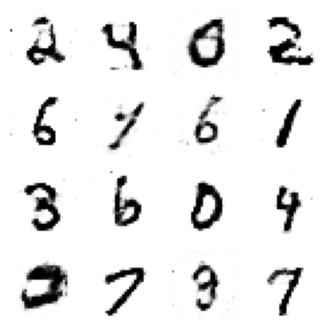

1        | 0.9897     | 3.1732     | 270.672754   | 0.5000  
10       | 0.5896     | 2.5827     | 20.034916    | 0.5000  
20       | 0.8725     | 1.7029     | 10.955494    | 0.5000  
30       | 0.9972     | 1.4412     | 9.767896     | 0.5000  
40       | 1.0976     | 1.2357     | 7.471462     | 0.5000  
50       | 1.1533     | 1.1190     | 5.876535     | 0.5000  
60       | 1.1888     | 1.0451     | 4.822443     | 0.5000  
70       | 1.2183     | 1.0108     | 4.690041     | 0.5000  
80       | 1.2290     | 0.9951     | 4.947910     | 0.5000  
90       | 1.2455     | 0.9489     | 3.827513     | 0.5000  
100      | 1.2476     | 0.9600     | 4.593812     | 0.5000  
110      | 1.2669     | 0.9129     | 3.456938     | 0.5000  
120      | 1.2615     | 0.9306     | 4.082247     | 0.5000  
130      | 1.2623     | 0.9265     | 4.070234     | 0.5000  
140      | 1.2693     | 0.9105     | 3.937081     | 0.5000  
150      | 1.2796     | 0.8975     | 3.674800     | 0.5000  
160      | 1.2739     | 

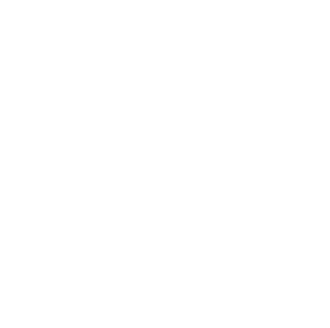

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


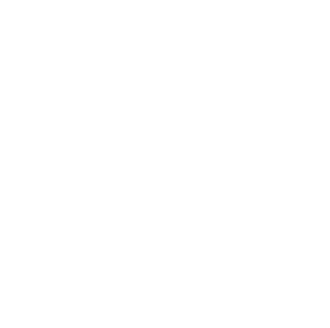

In [4]:
if __name__ == "__main__":
    main(only=["v6_logistic_fixed_sigma0p5",
               "v7_logistic_adaptive_sigma0p2"])


>>> 开始变体实验: v7_logistic_adaptive_sigma0p2
    config: final_activation=Vsig, dropout=0.3, instance_noise=0.0, label_smoothing=0.0, device=cuda
Epoch    | D Loss     | G Loss     | Grad Norm^2  | Sigma   
-----------------------------------------------------------------


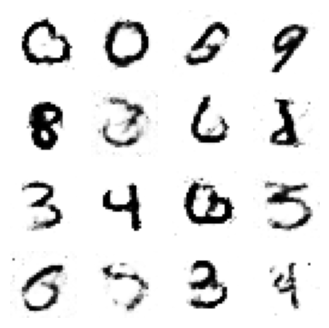

1        | 0.5279     | 6.6750     | 613.037308   | 0.2148  
10       | 0.4924     | 3.0558     | 23.561213    | 0.2691  
20       | 0.8134     | 1.9476     | 13.259905    | 0.3561  
30       | 0.9628     | 1.5099     | 9.352732     | 0.4241  
40       | 1.0904     | 1.2464     | 6.522532     | 0.5072  
50       | 1.1640     | 1.0998     | 4.694994     | 0.6139  
60       | 1.1734     | 1.0806     | 4.722230     | 0.7194  
70       | 1.2116     | 1.0094     | 4.141475     | 0.8381  
80       | 1.2329     | 0.9789     | 3.898171     | 0.9752  
90       | 1.2360     | 0.9615     | 3.699298     | 1.1189  
100      | 1.2448     | 0.9531     | 3.739552     | 1.2543  
110      | 1.2449     | 0.9377     | 3.511098     | 1.3976  
120      | 1.2519     | 0.9290     | 3.632408     | 1.5389  
130      | 1.2668     | 0.9114     | 3.473097     | 1.6947  
140      | 1.2740     | 0.8882     | 2.954940     | 1.8435  
150      | 1.2743     | 0.8975     | 3.441040     | 2.0003  
160      | 1.2728     | 

In [3]:
if __name__ == "__main__":
    main(only=["v7_logistic_adaptive_sigma0p2"])


>>> 开始变体实验: v5_logistic_fixed_sigma0p2
    config: final_activation=Vsig, dropout=0.3, instance_noise=0.0, label_smoothing=0.0, device=cuda
Epoch    | D Loss     | G Loss     | Grad Norm^2  | Sigma   
-----------------------------------------------------------------


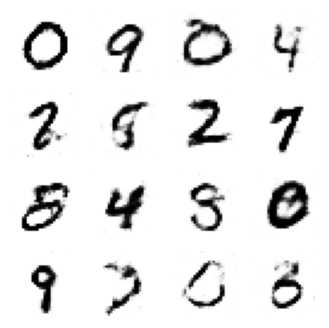

1        | 0.6243     | 6.5320     | 579.198566   | 0.2000  
10       | 0.5323     | 2.8528     | 27.512036    | 0.2000  
20       | 0.7901     | 1.9870     | 18.298043    | 0.2000  
30       | 0.9801     | 1.5096     | 11.984082    | 0.2000  
40       | 1.0821     | 1.2486     | 7.140810     | 0.2000  
50       | 1.1398     | 1.1416     | 5.883923     | 0.2000  
60       | 1.1800     | 1.0903     | 5.539747     | 0.2000  
70       | 1.2050     | 1.0271     | 4.858165     | 0.2000  
80       | 1.2178     | 1.0062     | 4.735692     | 0.2000  
90       | 1.2281     | 0.9990     | 5.127901     | 0.2000  
100      | 1.2470     | 0.9682     | 4.547398     | 0.2000  
110      | 1.2393     | 0.9826     | 5.326699     | 0.2000  
120      | 1.2449     | 0.9622     | 5.027145     | 0.2000  
130      | 1.2600     | 0.9468     | 4.794931     | 0.2000  
140      | 1.2550     | 0.9510     | 5.024954     | 0.2000  
150      | 1.2660     | 0.9322     | 5.046306     | 0.2000  
160      | 1.2645     | 

In [4]:
if __name__ == "__main__":
    main(only=["v5_logistic_fixed_sigma0p2"])

In [8]:
# =============================================================================
# 把 7 个变体的 results.json 重新汇总 + 画 ablation 对比图 (IEEE 风格)
# =============================================================================
# 用法: 在 JupyterLab 里 %run mnist_ablation_plot.py, 或在 terminal 跑 python.
# 假设所有结果都在 D:/PRE2025/resultsablation/<variant_name>/ 下.

import os
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

# IEEE 风格 (和 Figcifarhist 相同, 需要 scienceplots)
try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'ieee'])
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 1000
    mpl.rcParams['axes.unicode_minus'] = False
    print("scienceplots / IEEE style enabled.")
except Exception as e:
    mpl.rcParams['figure.dpi'] = 400
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['mathtext.fontset'] = 'cm'
    mpl.rcParams['axes.unicode_minus'] = False
    mpl.rcParams['axes.linewidth'] = 0.5
    print(f"scienceplots not available ({e}), fallback to plain serif.")


RESULTS_ROOT = "D:/PRE2025/resultsablation/"

VARIANT_NAMES = [
    "v1_sigmoid",
    "v2_sigmoid_instance_noise",
    "v3_sigmoid_label_smooth",
    "v4_sigmoid_dropout05",
    "v5_logistic_fixed_sigma0p2",
    "v6_logistic_fixed_sigma0p5",
    "v7_logistic_adaptive_sigma0p2",
]

# Short labels for legends (match paper roman numerals i..vii).
LABELS = {
    "v1_sigmoid":                    r"(i) Sigmoid",
    "v2_sigmoid_instance_noise":     r"(ii) + inst. noise",
    "v3_sigmoid_label_smooth":       r"(iii) + label smooth",
    "v4_sigmoid_dropout05":          r"(iv) + dropout $0.5$",
    "v5_logistic_fixed_sigma0p2":    r"(v) fixed $\sigma=0.2$",
    "v6_logistic_fixed_sigma0p5":    r"(vi) fixed $\sigma=0.5$",
    "v7_logistic_adaptive_sigma0p2": r"(vii) adaptive $\sigma$",
}

# 统一 7 种颜色 / marker, 用于所有 ablation 图
COLORS = {
    "v1_sigmoid":                    "#000000",
    "v2_sigmoid_instance_noise":     "#E64B35",
    "v3_sigmoid_label_smooth":       "#4DBBD5",
    "v4_sigmoid_dropout05":          "#00A087",
    "v5_logistic_fixed_sigma0p2":    "#FF7F0E",
    "v6_logistic_fixed_sigma0p5":    "#8C564B",
    "v7_logistic_adaptive_sigma0p2": "#D62728",
}
MARKERS = {
    "v1_sigmoid":                    "o",
    "v2_sigmoid_instance_noise":     "s",
    "v3_sigmoid_label_smooth":       "^",
    "v4_sigmoid_dropout05":          "D",
    "v5_logistic_fixed_sigma0p2":    "v",
    "v6_logistic_fixed_sigma0p5":    "P",
    "v7_logistic_adaptive_sigma0p2": "*",
}


# =============================================================================
# 1. 从 7 个子目录重新聚合 summary.json
# =============================================================================
def rebuild_summary():
    summary = {}
    missing = []
    for name in VARIANT_NAMES:
        res_path = os.path.join(RESULTS_ROOT, name, "results.json")
        if not os.path.isfile(res_path):
            missing.append(name)
            continue
        with open(res_path, "r") as f:
            summary[name] = json.load(f)
    out_path = os.path.join(RESULTS_ROOT, "summary.json")
    with open(out_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"汇总完成: {out_path}")
    print(f"  找到 {len(summary)} 个变体: {list(summary.keys())}")
    if missing:
        print(f"  !! 缺失: {missing}")
    return summary


# =============================================================================
# 2. 加载每个变体的 epoch-level 曲线
# =============================================================================
def load_curves(name):
    d = os.path.join(RESULTS_ROOT, name)
    curves = {}
    for key, fn in [("d_loss",    "epoch_d_loss.npy"),
                    ("g_loss",    "epoch_g_loss.npy"),
                    ("grad_norm", "epoch_grad_norm.npy"),
                    ("sigma",     "epoch_sigma.npy")]:
        p = os.path.join(d, fn)
        curves[key] = np.load(p) if os.path.isfile(p) else None
    return curves


# =============================================================================
# 3. FigAblation.eps  —  generator gradient norm ||grad||_2 (linear y-axis)
#    注意: epoch_grad_norm.npy 保存的是 sum of squares (见训练脚本),
#    这里开方画 ||grad||_2, 与论文符号 ||∇L_G||_2 一致.
# =============================================================================
def plot_grad_norm(all_curves, save_path):
    fig, ax = plt.subplots(figsize=(3.4, 2.6))
    for name in VARIANT_NAMES:
        c = all_curves.get(name)
        if c is None or c["grad_norm"] is None:
            continue
        # 原始 .npy 是 ||grad||^2, 开方后就是 ||grad||_2
        y = np.sqrt(np.asarray(c["grad_norm"]))
        x = np.arange(1, len(y) + 1)
        ax.plot(x, y, color=COLORS[name], lw=0.8, label=LABELS[name])

    for spine in ax.spines.values():
        spine.set_linewidth(0.5); spine.set_color('gray')
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel(r"$\|\nabla_\theta \mathcal{L}_G^{\mathrm{ns}}\|_2$", fontsize=9)
    ax.tick_params(axis='x', which='both', top=False,   labelsize=8, width=0.5, color='gray')
    ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
    ax.legend(fontsize=6, loc='upper right', frameon=False,
              handlelength=1.2, labelspacing=0.25, borderpad=0.25,
              ncol=2, columnspacing=0.6)

    plt.tight_layout()
    fig.savefig(save_path + ".pdf", bbox_inches="tight")
    fig.savefig(save_path + ".eps", bbox_inches="tight")
    fig.savefig(save_path + ".png", dpi=400, bbox_inches="tight")
    print(f"  saved: {save_path}.(pdf|eps|png)")
    plt.close(fig)


# =============================================================================
# 4. FigAblationHist.eps  —  only the FIVE successful variants on ONE figure
#    (collapsed ones i, iii are omitted; the text describes them.)
# =============================================================================
def plot_mode_counts(summary, save_path):
    successful = [
        "v2_sigmoid_instance_noise",
        "v4_sigmoid_dropout05",
        "v5_logistic_fixed_sigma0p2",
        "v6_logistic_fixed_sigma0p5",
        "v7_logistic_adaptive_sigma0p2",
    ]
    if not all(n in summary for n in successful):
        missing = [n for n in successful if n not in summary]
        print(f"  plot_mode_counts: 缺失变体 {missing}, 跳过")
        return

    def counts_of(name):
        cc = summary[name]["class_counts"]
        return np.array([cc.get(str(i), cc.get(i, 0)) for i in range(10)])

    offsets = np.linspace(-0.28, 0.28, len(successful))

    fig, ax = plt.subplots(figsize=(3.4, 2.6))
    x_cls = np.arange(10)
    for name, off in zip(successful, offsets):
        c = counts_of(name)
        col = COLORS[name]; mk = MARKERS[name]
        ax.vlines(x_cls + off, 0, c, colors=col, linewidth=0.8, zorder=2)
        ax.plot(x_cls + off, c, linestyle='None', marker=mk, color=col,
                markersize=2.8, markerfacecolor='white',
                markeredgecolor=col, markeredgewidth=0.6,
                zorder=3, label=LABELS[name])
    ax.axhline(100, color='gray', linestyle='--', linewidth=0.6, zorder=1)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5); spine.set_color('gray')
    ax.set_xlabel('Class', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks(x_cls)
    ax.tick_params(axis='x', which='both', top=False, labelsize=8, width=0.5, color='gray')
    ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(0, 200)
    ax.legend(fontsize=6, loc='upper right', frameon=False,
              handlelength=1.2, labelspacing=0.25, borderpad=0.25,
              ncol=2, columnspacing=0.6)

    plt.tight_layout()
    fig.savefig(save_path + ".pdf", bbox_inches="tight")
    fig.savefig(save_path + ".eps", bbox_inches="tight")
    fig.savefig(save_path + ".png", dpi=400, bbox_inches="tight")
    print(f"  saved: {save_path}.(pdf|eps|png)")
    plt.close(fig)


# =============================================================================
# 5. 打印一个 ASCII 汇总表
# =============================================================================
def print_table(summary):
    print("\n" + "=" * 80)
    print("ABLATION SUMMARY")
    print("=" * 80)
    hdr = (f"{'Variant':32s} | {'IS':>17s} | {'FID':>8s} | {'Modes':>6s}")
    print(hdr)
    print("-" * len(hdr))
    for name in VARIANT_NAMES:
        if name not in summary:
            print(f"{LABELS[name]:32s} |   [not found]")
            continue
        r = summary[name]
        is_m, is_s = r["IS"]
        fid = r["FID"]
        modes = r["Modes"]
        print(f"{LABELS[name]:32s} | {is_m:7.4f} +- {is_s:5.4f} | "
              f"{fid:8.4f} | {modes:>3d}/10")

    print("\nClass counts (out of 1000 generated samples):")
    for name in VARIANT_NAMES:
        if name not in summary:
            continue
        cc = summary[name].get("class_counts", {})
        ordered = {i: cc.get(str(i), cc.get(i, 0)) for i in range(10)}
        print(f"  {LABELS[name]:32s}: {ordered}")


# =============================================================================
# 6. 主入口
# =============================================================================
def main():
    summary = rebuild_summary()

    all_curves = {}
    for name in VARIANT_NAMES:
        if name in summary:
            all_curves[name] = load_curves(name)

    plot_grad_norm(all_curves, os.path.join(RESULTS_ROOT, "FigAblation"))
    plot_mode_counts(summary,  os.path.join(RESULTS_ROOT, "FigAblationHist"))

    print_table(summary)


if __name__ == "__main__":
    main()

scienceplots / IEEE style enabled.
汇总完成: D:/PRE2025/resultsablation/summary.json
  找到 7 个变体: ['v1_sigmoid', 'v2_sigmoid_instance_noise', 'v3_sigmoid_label_smooth', 'v4_sigmoid_dropout05', 'v5_logistic_fixed_sigma0p2', 'v6_logistic_fixed_sigma0p5', 'v7_logistic_adaptive_sigma0p2']
  saved: D:/PRE2025/resultsablation/FigAblation.(pdf|eps|png)
  saved: D:/PRE2025/resultsablation/FigAblationHist.(pdf|eps|png)

ABLATION SUMMARY
Variant                          |                IS |      FID |  Modes
------------------------------------------------------------------------
(i) Sigmoid                      |  1.0211 +- 0.0032 |   0.0581 |   1/10
(ii) + inst. noise               |  8.8339 +- 0.1912 |   0.0003 |  10/10
(iii) + label smooth             |  1.0000 +- 0.0000 |   0.7569 |   1/10
(iv) + dropout $0.5$             |  8.8244 +- 0.2047 |   0.0004 |  10/10
(v) fixed $\sigma=0.2$           |  8.9012 +- 0.2617 |   0.0005 |  10/10
(vi) fixed $\sigma=0.5$          |  8.8228 +- 0.2367 |   0.000

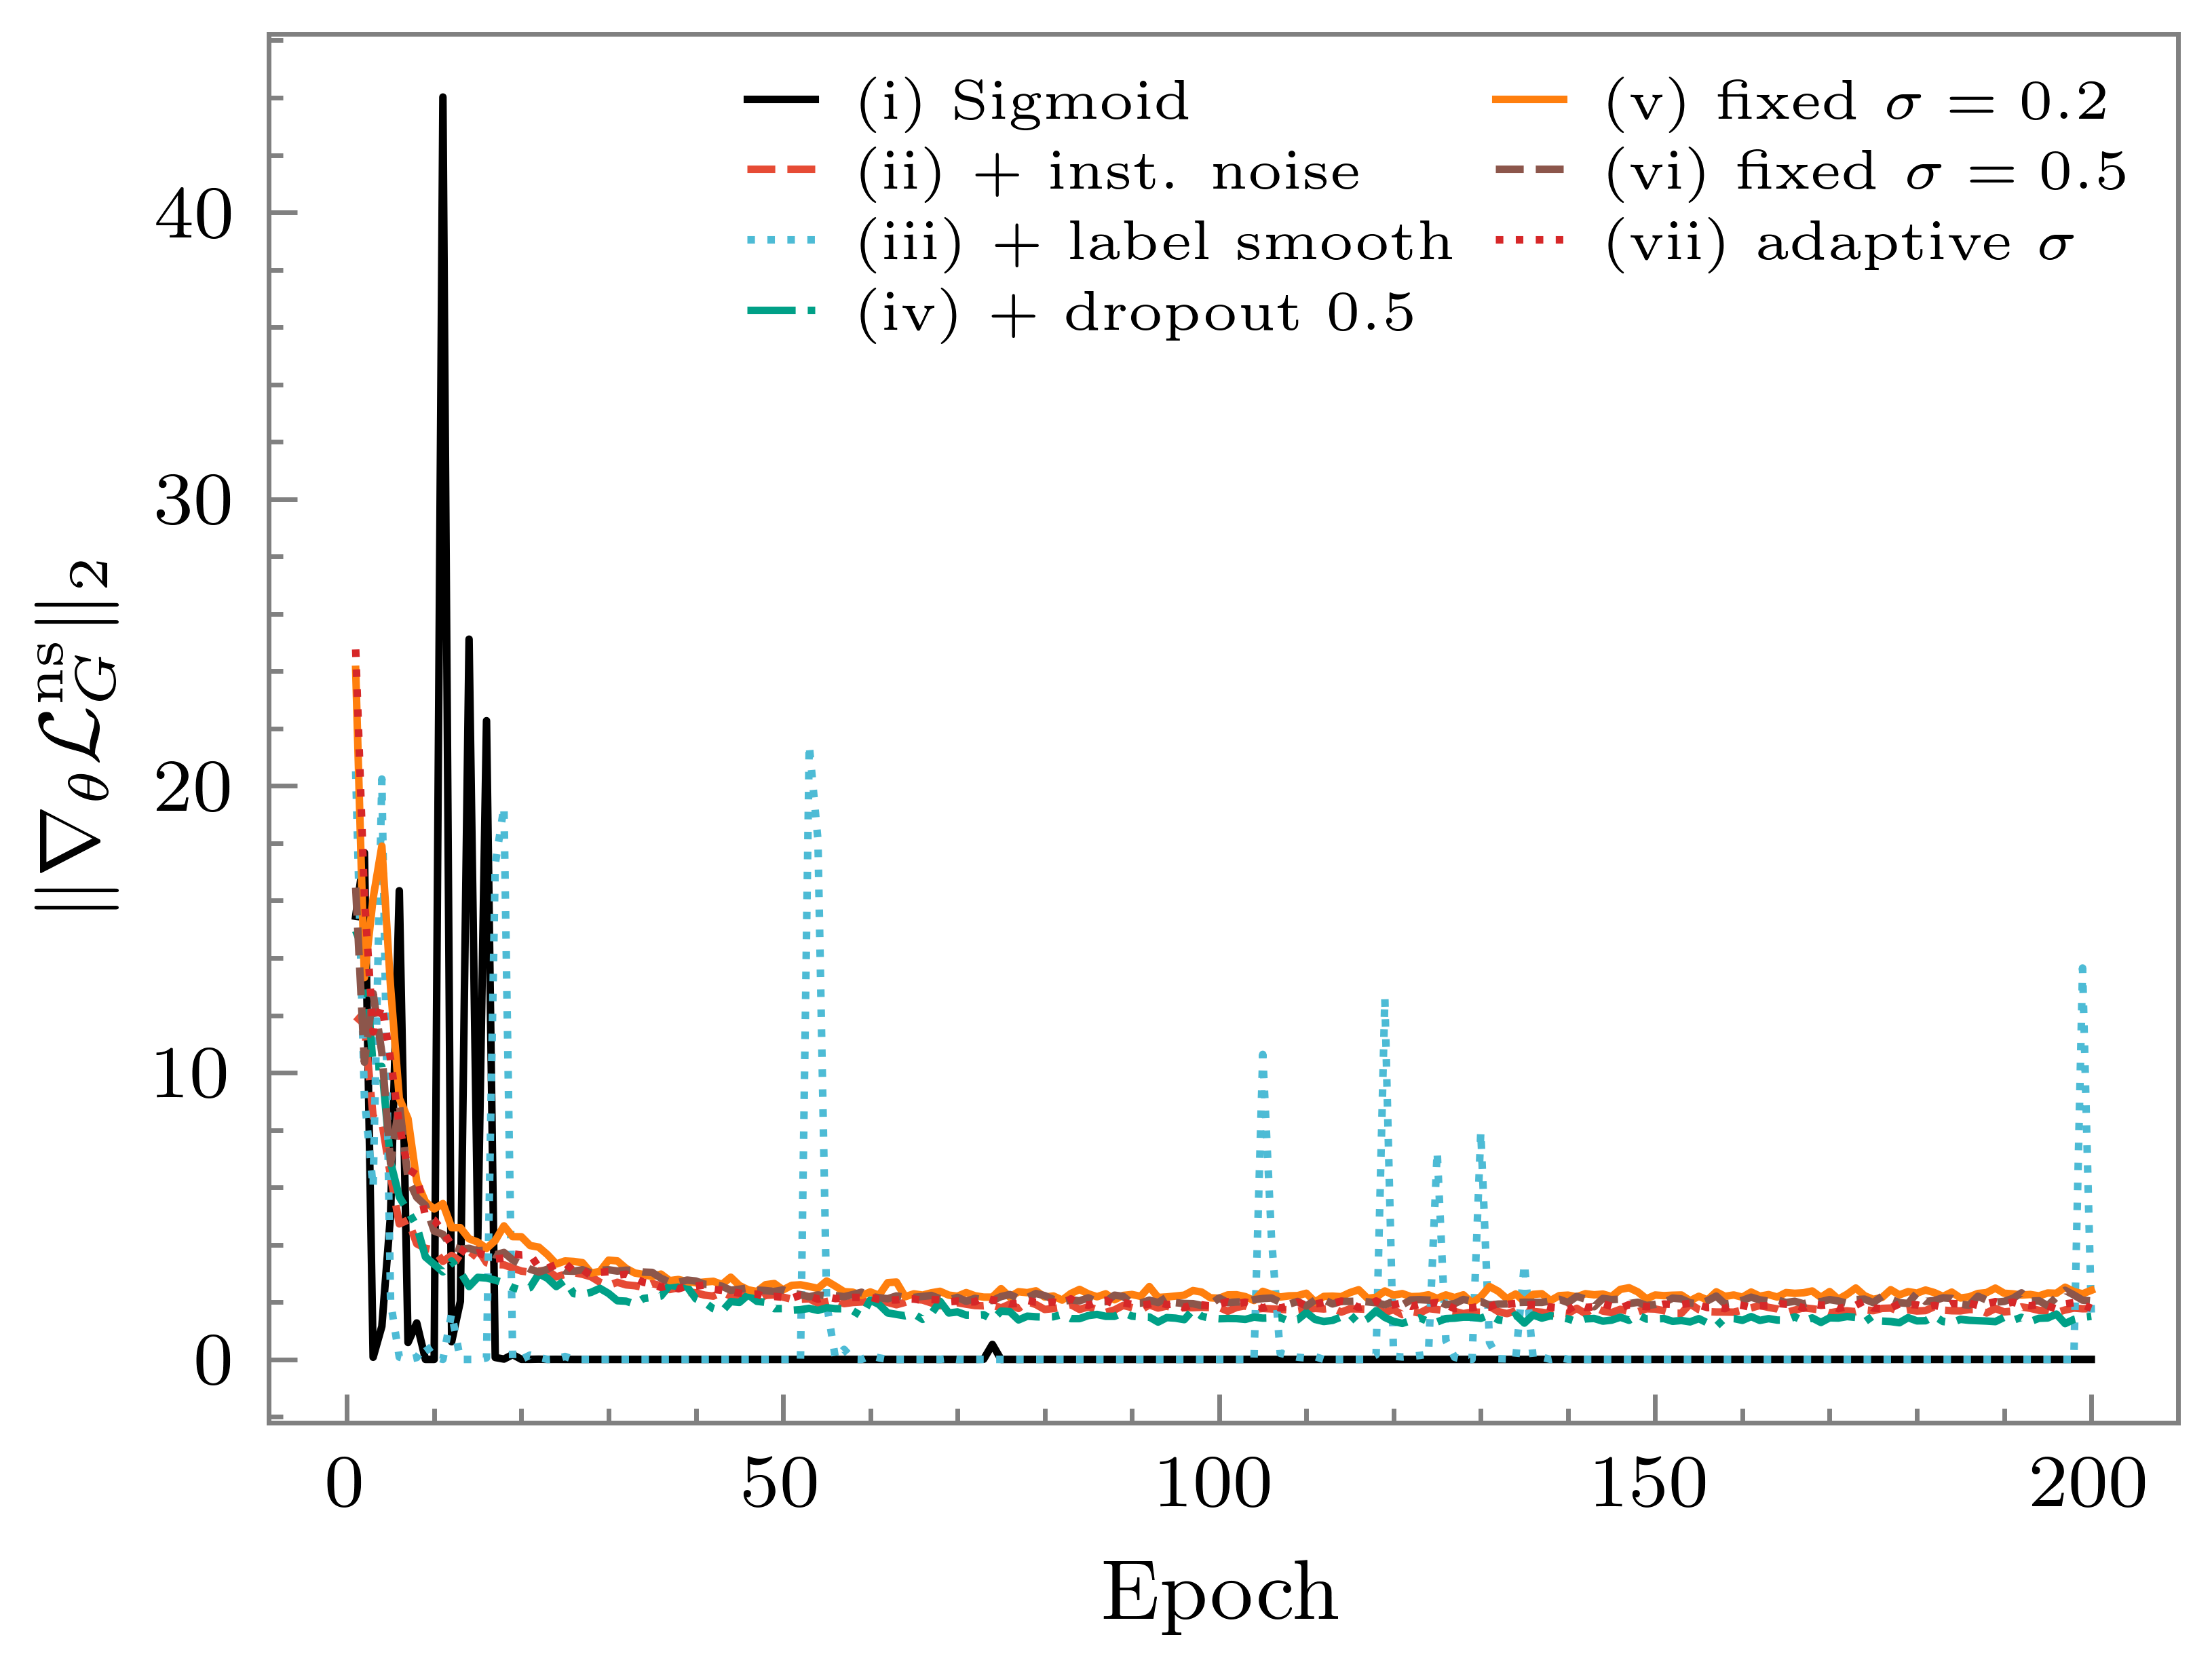

In [9]:
# =============================================================================
# FigAblation.eps  —  generator gradient norm  ||∇ L_G^ns||_2 , linear y-axis
# 风格与 Figcifarhist 一致; 在 JupyterLab 中直接运行此 cell 即可显示
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2025/resultsablation"

variants = {
    r"(i) Sigmoid":                 f"{BASE}/v1_sigmoid/epoch_grad_norm.npy",
    r"(ii) + inst. noise":          f"{BASE}/v2_sigmoid_instance_noise/epoch_grad_norm.npy",
    r"(iii) + label smooth":        f"{BASE}/v3_sigmoid_label_smooth/epoch_grad_norm.npy",
    r"(iv) + dropout $0.5$":        f"{BASE}/v4_sigmoid_dropout05/epoch_grad_norm.npy",
    r"(v) fixed $\sigma=0.2$":      f"{BASE}/v5_logistic_fixed_sigma0p2/epoch_grad_norm.npy",
    r"(vi) fixed $\sigma=0.5$":     f"{BASE}/v6_logistic_fixed_sigma0p5/epoch_grad_norm.npy",
    r"(vii) adaptive $\sigma$":     f"{BASE}/v7_logistic_adaptive_sigma0p2/epoch_grad_norm.npy",
}

# .npy 里存的是 ||grad||^2 (sum of squares), 开方得到 ||grad||_2
curves = {lab: np.sqrt(np.load(p)) for lab, p in variants.items()}
labels = list(curves.keys())

colors  = ['#000000', '#E64B35', '#4DBBD5', '#00A087',
           '#FF7F0E', '#8C564B', '#D62728']

fig, ax = plt.subplots(figsize=(3.4, 2.6))
for lab, col in zip(labels, colors):
    y = curves[lab]
    x = np.arange(1, len(y) + 1)
    ax.plot(x, y, color=col, linewidth=0.8, label=lab)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel(r'$\|\nabla_\theta \mathcal{L}_G^{\mathrm{ns}}\|_2$', fontsize=9)
ax.tick_params(axis='x', which='both', top=False,   labelsize=8, width=0.5, color='gray')
ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
ax.legend(fontsize=6, loc='upper right', frameon=False,
          handlelength=1.2, labelspacing=0.25, borderpad=0.25,
          ncol=2, columnspacing=0.6)

plt.tight_layout()
plt.savefig('D:/PRE2025/FigAblation.eps', dpi=1000, bbox_inches='tight')
plt.show()

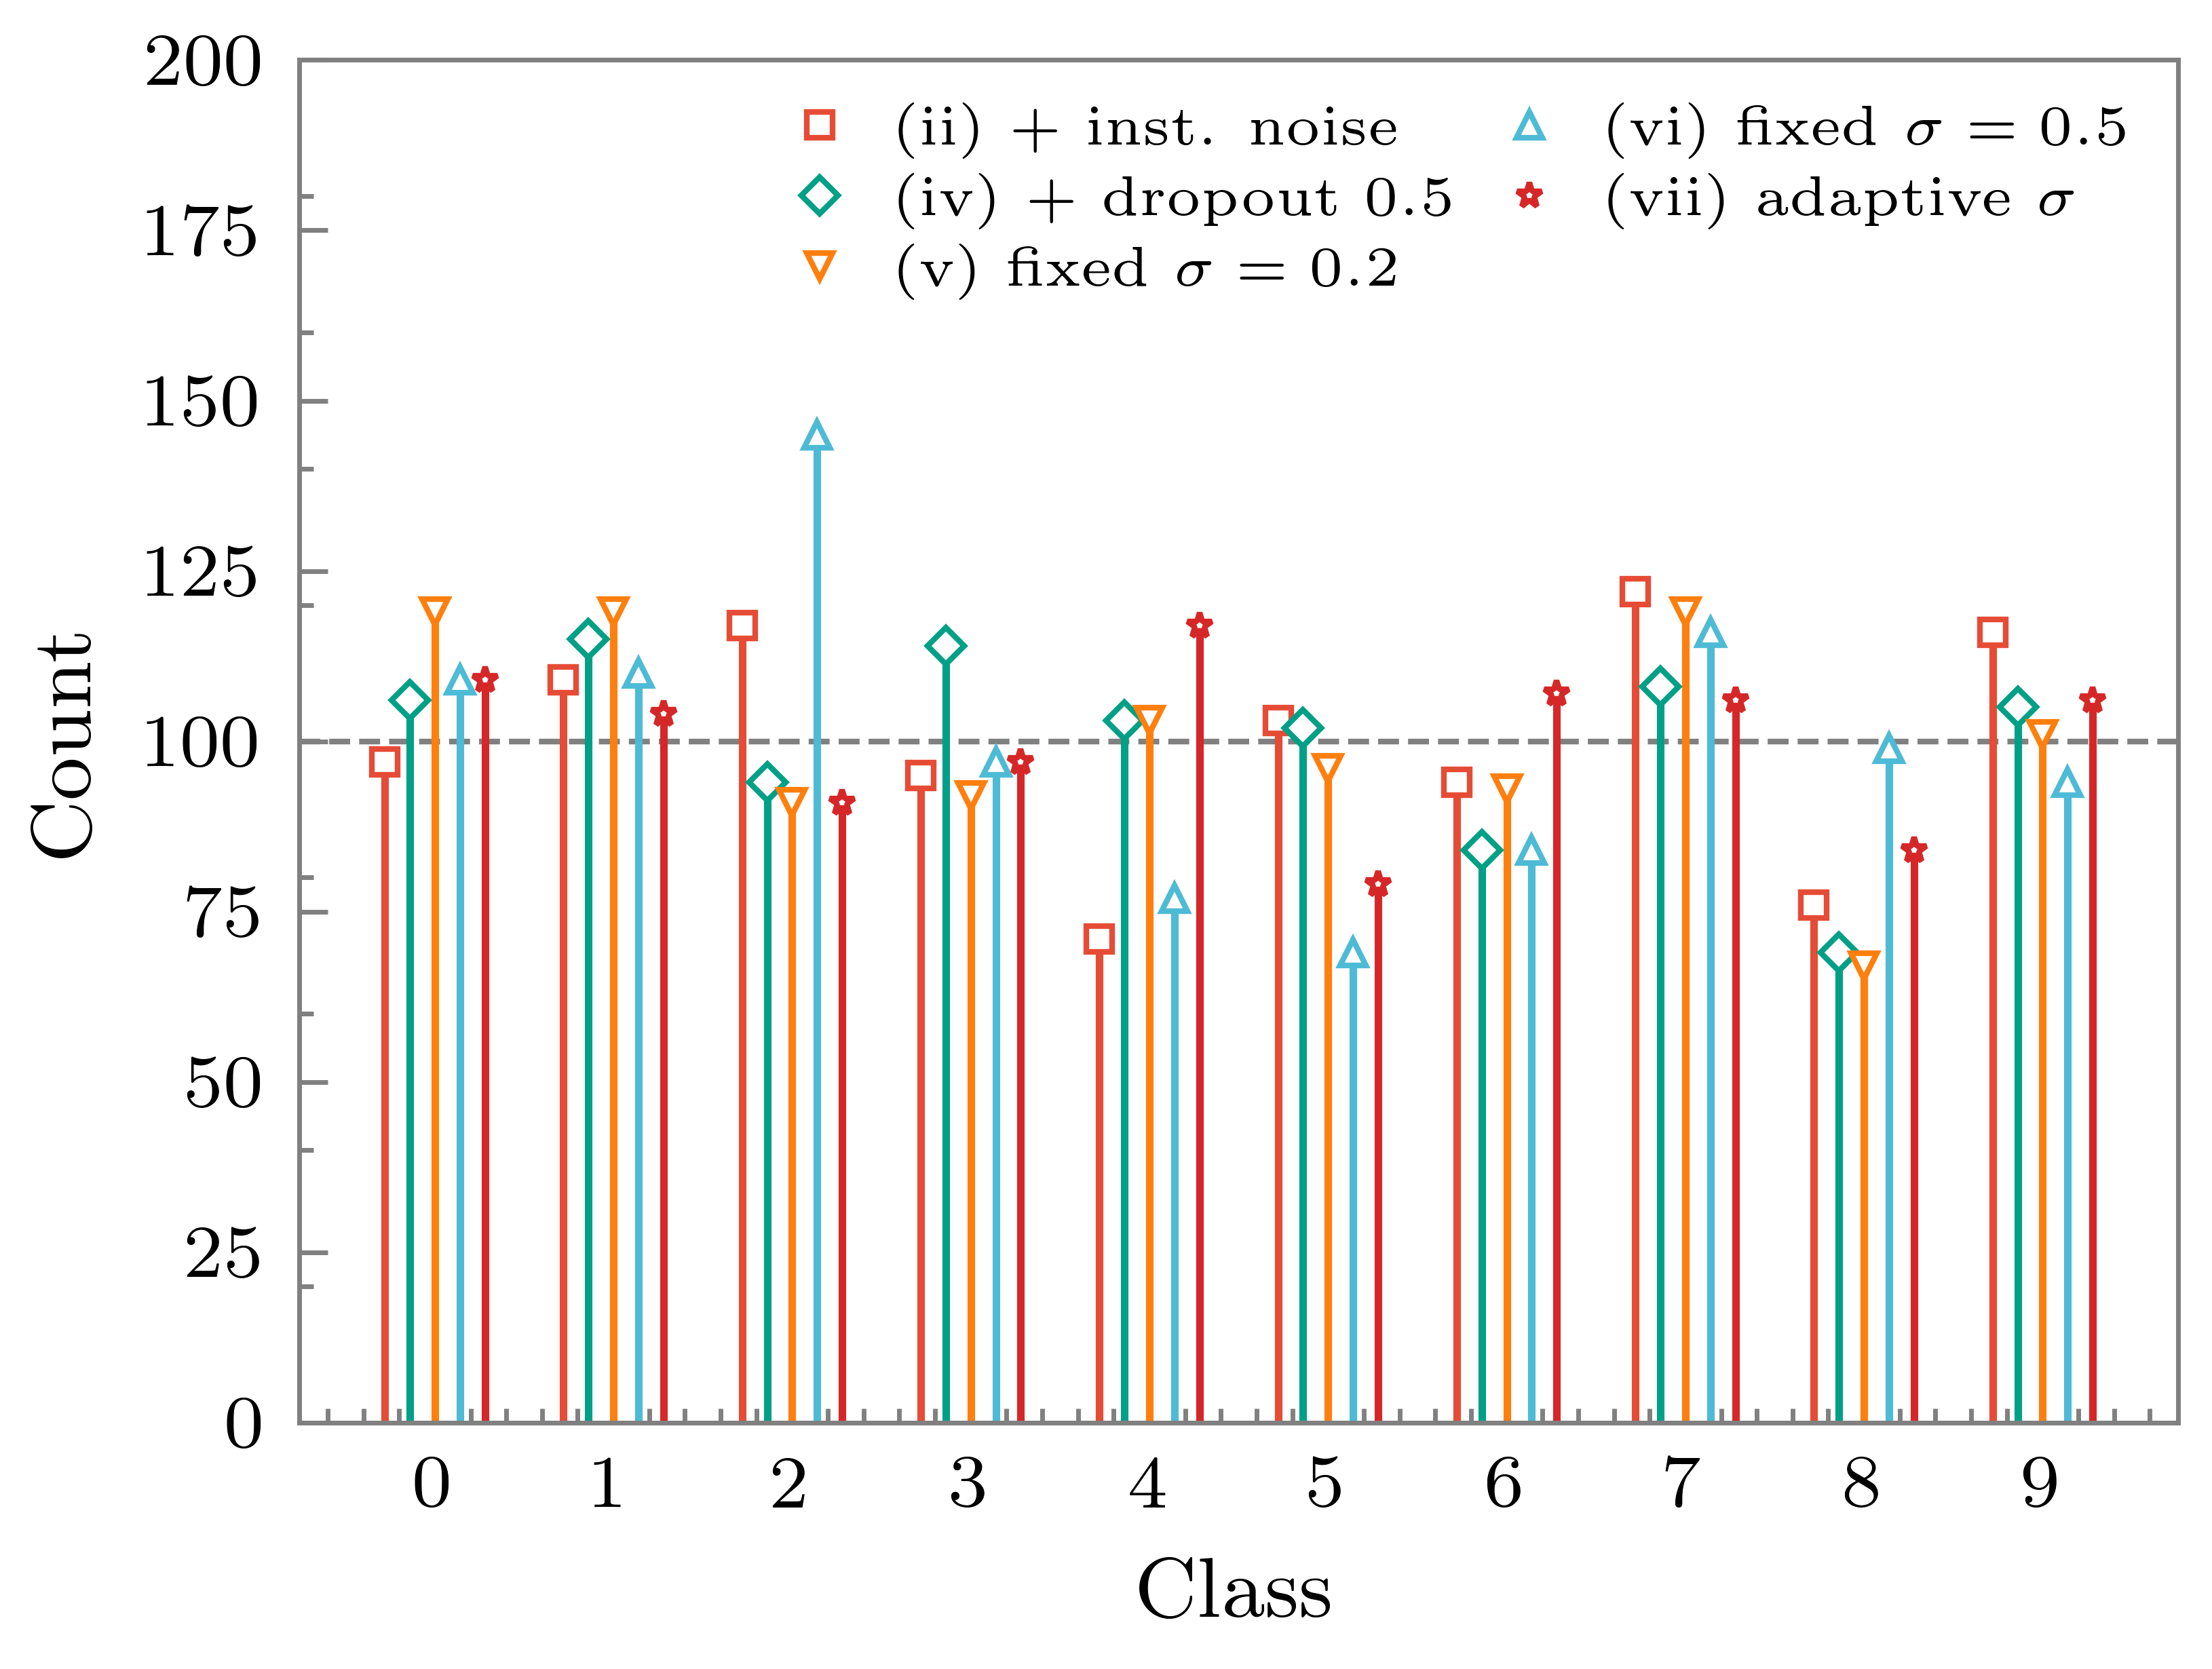

In [10]:
# =============================================================================
# FigAblationHist.eps  —  class-wise counts of 1000 generated digits
# only the 5 variants that avoid mode collapse (i and iii are omitted)
# 风格与 Figcifarhist 完全一致; 在 JupyterLab 中直接运行此 cell 即可显示
# =============================================================================

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from matplotlib.ticker import MultipleLocator
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2025/resultsablation"

variants = {
    r"(ii) + inst. noise":        f"{BASE}/v2_sigmoid_instance_noise/results.json",
    r"(iv) + dropout $0.5$":      f"{BASE}/v4_sigmoid_dropout05/results.json",
    r"(v) fixed $\sigma=0.2$":    f"{BASE}/v5_logistic_fixed_sigma0p2/results.json",
    r"(vi) fixed $\sigma=0.5$":   f"{BASE}/v6_logistic_fixed_sigma0p5/results.json",
    r"(vii) adaptive $\sigma$":   f"{BASE}/v7_logistic_adaptive_sigma0p2/results.json",
}

def load_counts(path):
    r = json.load(open(path))
    cc = r["class_counts"]
    return np.array([cc.get(str(i), cc.get(i, 0)) for i in range(10)])

counts  = {lab: load_counts(p) for lab, p in variants.items()}
labels  = list(counts.keys())
colors  = ['#E64B35', '#00A087', '#FF7F0E', '#4DBBD5', '#D62728']
markers = ['s',       'D',       'v',       '^',       '*']
offsets = np.linspace(-0.28, 0.28, 5)

x = np.arange(10)
fig, ax = plt.subplots(figsize=(3.4, 2.6))

for lab, col, mk, off in zip(labels, colors, markers, offsets):
    c = counts[lab]
    ax.vlines(x + off, 0, c, colors=col, linewidth=0.8, zorder=2)
    ax.plot(x + off, c, linestyle='None', marker=mk, color=col,
            markersize=2.8,
            markerfacecolor='white',
            markeredgecolor=col,
            markeredgewidth=0.6,
            zorder=3,
            label=lab)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.6, zorder=1)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax.set_xlabel('Class', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_xticks(x)
ax.tick_params(axis='x', which='both', top=False,   labelsize=8, width=0.5, color='gray')
ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(0, 200)
ax.legend(fontsize=6, loc='upper right', frameon=False,
          handlelength=1.2, labelspacing=0.25, borderpad=0.25,
          ncol=2, columnspacing=0.6)

plt.tight_layout()
plt.savefig('D:/PRE2025/FigAblationHist.eps', dpi=1000, bbox_inches='tight')
plt.show()


>>> 开始变体实验: v8_sigmoid_act_noise
    config: final_activation=sigmoid, dropout=0.3, ACT_NOISE_STD=0.1 (injected after each LeakyReLU), device=cuda
Epoch    | D Loss     | G Loss     | Grad Norm^2  | Sigma   
-----------------------------------------------------------------


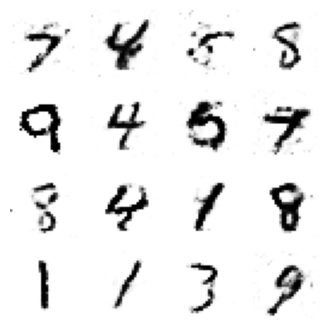

1        | 1.0322     | 2.3515     | 86.006706    | 1.0000  
10       | 0.7033     | 2.1671     | 16.109771    | 1.0000  
20       | 0.9354     | 1.5639     | 10.020941    | 1.0000  
30       | 1.0503     | 1.2972     | 7.365621     | 1.0000  
40       | 1.1292     | 1.1570     | 5.960312     | 1.0000  
50       | 1.1611     | 1.0983     | 5.798631     | 1.0000  
60       | 1.2057     | 1.0140     | 4.055255     | 1.0000  
70       | 1.2296     | 0.9798     | 3.973956     | 1.0000  
80       | 1.2422     | 0.9665     | 4.104287     | 1.0000  
90       | 1.2609     | 0.9287     | 3.528741     | 1.0000  
100      | 1.2596     | 0.9249     | 3.585340     | 1.0000  
110      | 1.2741     | 0.9116     | 3.485612     | 1.0000  
120      | 1.2750     | 0.8948     | 3.367762     | 1.0000  
130      | 1.2732     | 0.9018     | 3.309729     | 1.0000  
140      | 1.2772     | 0.8983     | 3.610684     | 1.0000  
150      | 1.2790     | 0.8919     | 3.484173     | 1.0000  
160      | 1.2907     | 

In [2]:
# =============================================================================
# v8  —  Sigmoid + activation noise in discriminator hidden layers
# 单独的 cell, 直接粘贴到 JupyterLab 运行即可 (依赖前面 cell 里已定义的
# train_variant / Generator / SimpleCNN / FeatureExtractor / 全局常量 等).
# 
# 机制说明: 在每个 LeakyReLU 的输出上加 N(0, s^2) 高斯噪声 (仅 training 时),
# 再进 Dropout, 再进下一 Linear. 这是 reviewer 2 明确提到的
# "dropout/activation noise in the discriminator" 里面与 dropout 并列的那一种.
# 强度 s=0.1 与 v2 (instance noise) 保持一致, 便于横向对比.
# =============================================================================

import torch
import torch.nn as nn

class DiscriminatorActNoise(nn.Module):
    """Sigmoid discriminator with Gaussian activation noise injected after each
    LeakyReLU in the hidden layers. Structure is otherwise identical to the
    baseline Discriminator used in v1-v7."""

    def __init__(self, act_noise_std=0.1, dropout_rate=0.3):
        super().__init__()
        self.act_noise_std = float(act_noise_std)

        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 1)

        self.lrelu = nn.LeakyReLU(0.2, inplace=False)   # 不要 inplace, 噪声要加在 clone 上
        self.drop  = nn.Dropout(dropout_rate)
        self.sig   = nn.Sigmoid()

    def _noisy_activation(self, h):
        # LeakyReLU -> (+ Gaussian noise if training) -> Dropout
        h = self.lrelu(h)
        if self.training and self.act_noise_std > 0:
            h = h + self.act_noise_std * torch.randn_like(h)
        h = self.drop(h)
        return h

    def forward(self, x):
        x = x.view(x.size(0), 784)
        x = self._noisy_activation(self.fc1(x))
        x = self._noisy_activation(self.fc2(x))
        x = self._noisy_activation(self.fc3(x))
        x = self.sig(self.fc4(x))
        return x.view(-1, 1)


# =============================================================================
# v8 只改了 D 的类型, 其它训练流程与前面完全一致.
# 为了复用 train_variant(...), 我们在这里手写一个 v8 版本的训练循环
# (完全照搬 train_variant 的内容, 只是把 Discriminator 换成 DiscriminatorActNoise).
# =============================================================================
import os
import json
import itertools
from collections import Counter
import numpy as np
import torch.nn.functional as F
from IPython import display
import matplotlib.pyplot as plt
from scipy import linalg


def train_v8(name="v8_sigmoid_act_noise", act_noise_std=0.1):
    save_dir = os.path.join(SAVE_DIR_ROOT, name)
    os.makedirs(save_dir, exist_ok=True)

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    train_loader = make_train_loader()

    discriminator = DiscriminatorActNoise(act_noise_std=act_noise_std,
                                          dropout_rate=0.3).to(DEVICE)
    generator = Generator().to(DEVICE)
    criterion = nn.BCELoss()
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LR)
    g_optimizer = torch.optim.Adam(generator.parameters(),     lr=LR)

    epoch_d_loss, epoch_g_loss, epoch_generator_grad_norm, epoch_sigma = [], [], [], []

    print(f"\n>>> 开始变体实验: {name}")
    print(f"    config: final_activation=sigmoid, dropout=0.3, "
          f"ACT_NOISE_STD={act_noise_std} (injected after each LeakyReLU), device={DEVICE}")
    print(f"{'Epoch':<8} | {'D Loss':<10} | {'G Loss':<10} | {'Grad Norm^2':<12} | {'Sigma':<8}")
    print("-" * 65)

    test_noise = torch.randn(16, 100).to(DEVICE)
    fig, ax = plt.subplots(4, 4, figsize=(4, 4))
    for i, j in itertools.product(range(4), range(4)):
        ax[i, j].axis('off')
    dh = display.display(fig, display_id=True)

    for epoch in range(EPOCHS):
        batch_d_loss, batch_g_loss, batch_grad_norm = [], [], []

        for n, (real_imgs, _) in enumerate(train_loader):
            real_imgs = real_imgs.to(DEVICE)
            bsz = real_imgs.size(0)
            real_labels = torch.ones(bsz, 1, device=DEVICE)    # 无 label smoothing
            fake_labels = torch.zeros(bsz, 1, device=DEVICE)

            # D step
            z = torch.randn(bsz, 100, device=DEVICE)
            fake_imgs = generator(z)
            discriminator.zero_grad()
            d_loss = criterion(discriminator(real_imgs), real_labels) + \
                     criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # G step
            z = torch.randn(bsz, 100, device=DEVICE)
            fake_imgs = generator(z)
            generator.zero_grad()
            g_loss = criterion(discriminator(fake_imgs), torch.ones(bsz, 1, device=DEVICE))
            g_loss.backward()

            total_norm = 0.0
            for p in generator.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            batch_grad_norm.append(total_norm)
            g_optimizer.step()

            batch_d_loss.append(d_loss.item())
            batch_g_loss.append(g_loss.item())

            if (n + 1) % 500 == 0 and epoch % 20 == 0:
                test_imgs = generator(test_noise).detach().cpu()
                for k in range(16):
                    i, j = k // 4, k % 4
                    ax[i, j].cla(); ax[i, j].axis('off')
                    ax[i, j].imshow(1 - test_imgs[k].view(28, 28), cmap='gray')
                dh.update(fig)
                fig.savefig(os.path.join(save_dir, f"epoch_{epoch}.png"))

        epoch_d_loss.append(float(np.mean(batch_d_loss)))
        epoch_g_loss.append(float(np.mean(batch_g_loss)))
        epoch_generator_grad_norm.append(float(np.mean(batch_grad_norm)))
        epoch_sigma.append(1.0)     # sigmoid variant, sigma == 1 by convention

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{epoch+1:<8d} | {epoch_d_loss[-1]:<10.4f} | {epoch_g_loss[-1]:<10.4f} | "
                  f"{epoch_generator_grad_norm[-1]:<12.6f} | {1.0:<8.4f}")

    plt.close(fig)

    # ===== 保存曲线 =====
    np.save(os.path.join(save_dir, "epoch_d_loss.npy"),    np.array(epoch_d_loss))
    np.save(os.path.join(save_dir, "epoch_g_loss.npy"),    np.array(epoch_g_loss))
    np.save(os.path.join(save_dir, "epoch_grad_norm.npy"), np.array(epoch_generator_grad_norm))
    np.save(os.path.join(save_dir, "epoch_sigma.npy"),     np.array(epoch_sigma))

    torch.save(generator.state_dict(),     os.path.join(save_dir, "generator.pt"))
    torch.save(discriminator.state_dict(), os.path.join(save_dir, "discriminator.pt"))

    # ===== 4x4 可视化 =====
    generator.eval()
    with torch.no_grad():
        final_imgs_16 = generator(torch.randn(16, 100, device=DEVICE)).cpu().view(16, 28, 28)
    fig_f, axes = plt.subplots(4, 4, figsize=(6, 6))
    for k in range(16):
        axes[k // 4, k % 4].imshow(1 - final_imgs_16[k], cmap="gray")
        axes[k // 4, k % 4].axis("off")
    fig_f.suptitle(name)
    fig_f.tight_layout()
    fig_f.savefig(os.path.join(save_dir, "final_generated.png"), dpi=300)
    fig_f.savefig(os.path.join(save_dir, "final_generated.eps"), dpi=300)
    plt.close(fig_f)

    with torch.no_grad():
        samples_1000 = generator(torch.randn(1000, 100, device=DEVICE)).cpu().numpy()
        samples_1000 = samples_1000.reshape(-1, 28, 28).astype(np.float32)
    np.save(os.path.join(save_dir, "samples_1000.npy"), samples_1000)

    # ===== IS / FID / Mode coverage 评估 =====
    print(f"  [{name}] 训练完成, 正在进行最终指标评估...")
    eval_classifier = SimpleCNN().to(DEVICE)
    c_opt = torch.optim.Adam(eval_classifier.parameters(), lr=1e-3)
    eval_classifier.train()
    for _ in range(2):
        for x_, y_ in train_loader:
            x_, y_ = x_.to(DEVICE), y_.to(DEVICE)
            c_opt.zero_grad()
            F.cross_entropy(eval_classifier(x_), y_).backward()
            c_opt.step()

    eval_feat_ext = FeatureExtractor().to(DEVICE)
    generator.eval()
    with torch.no_grad():
        fake_ims = generator(torch.randn(1000, 100, device=DEVICE)).view(-1, 1, 28, 28)
        fake_feat = eval_feat_ext(fake_ims).cpu().numpy()
        real_ims = []
        for imgs, _ in train_loader:
            real_ims.append(imgs)
            if sum(z_.size(0) for z_ in real_ims) >= 1000:
                break
        real_feat = eval_feat_ext(torch.cat(real_ims, 0)[:1000].to(DEVICE)).cpu().numpy()

    is_m, is_s = calculate_inception_score(fake_ims, eval_classifier)
    fid_v = calculate_fid(real_feat, fake_feat)
    modes, kl_v, counts = calculate_mode_score(fake_ims, eval_classifier)

    results = {
        "IS":           [float(is_m), float(is_s)],
        "FID":          float(fid_v),
        "Modes":        int(modes),
        "KL":           float(kl_v),
        "class_counts": {int(k): int(v) for k, v in dict(counts).items()},
        "config": {
            "name":               name,
            "final_activation":   "sigmoid",
            "dropout_rate":       0.3,
            "act_noise_std":      act_noise_std,
            "instance_noise_std": 0.0,
            "label_smoothing":    0.0,
            "final_sigma":        1.0,
            "final_grad_norm_sq": epoch_generator_grad_norm[-1],
        },
    }
    with open(os.path.join(save_dir, "results.json"), "w") as f:
        json.dump(results, f, indent=2)

    print(f"  指标结果: IS={is_m:.4f}±{is_s:.4f}, FID={fid_v:.4f}, "
          f"Mode={modes}/10, KL={kl_v:.4f}")
    print(f"  class_counts={dict(counts)}")
    print(f"  final_grad_sq={epoch_generator_grad_norm[-1]:.6f}")
    return results


# =============================================================================
# 运行 v8
# =============================================================================
if __name__ == "__main__":
    train_v8()

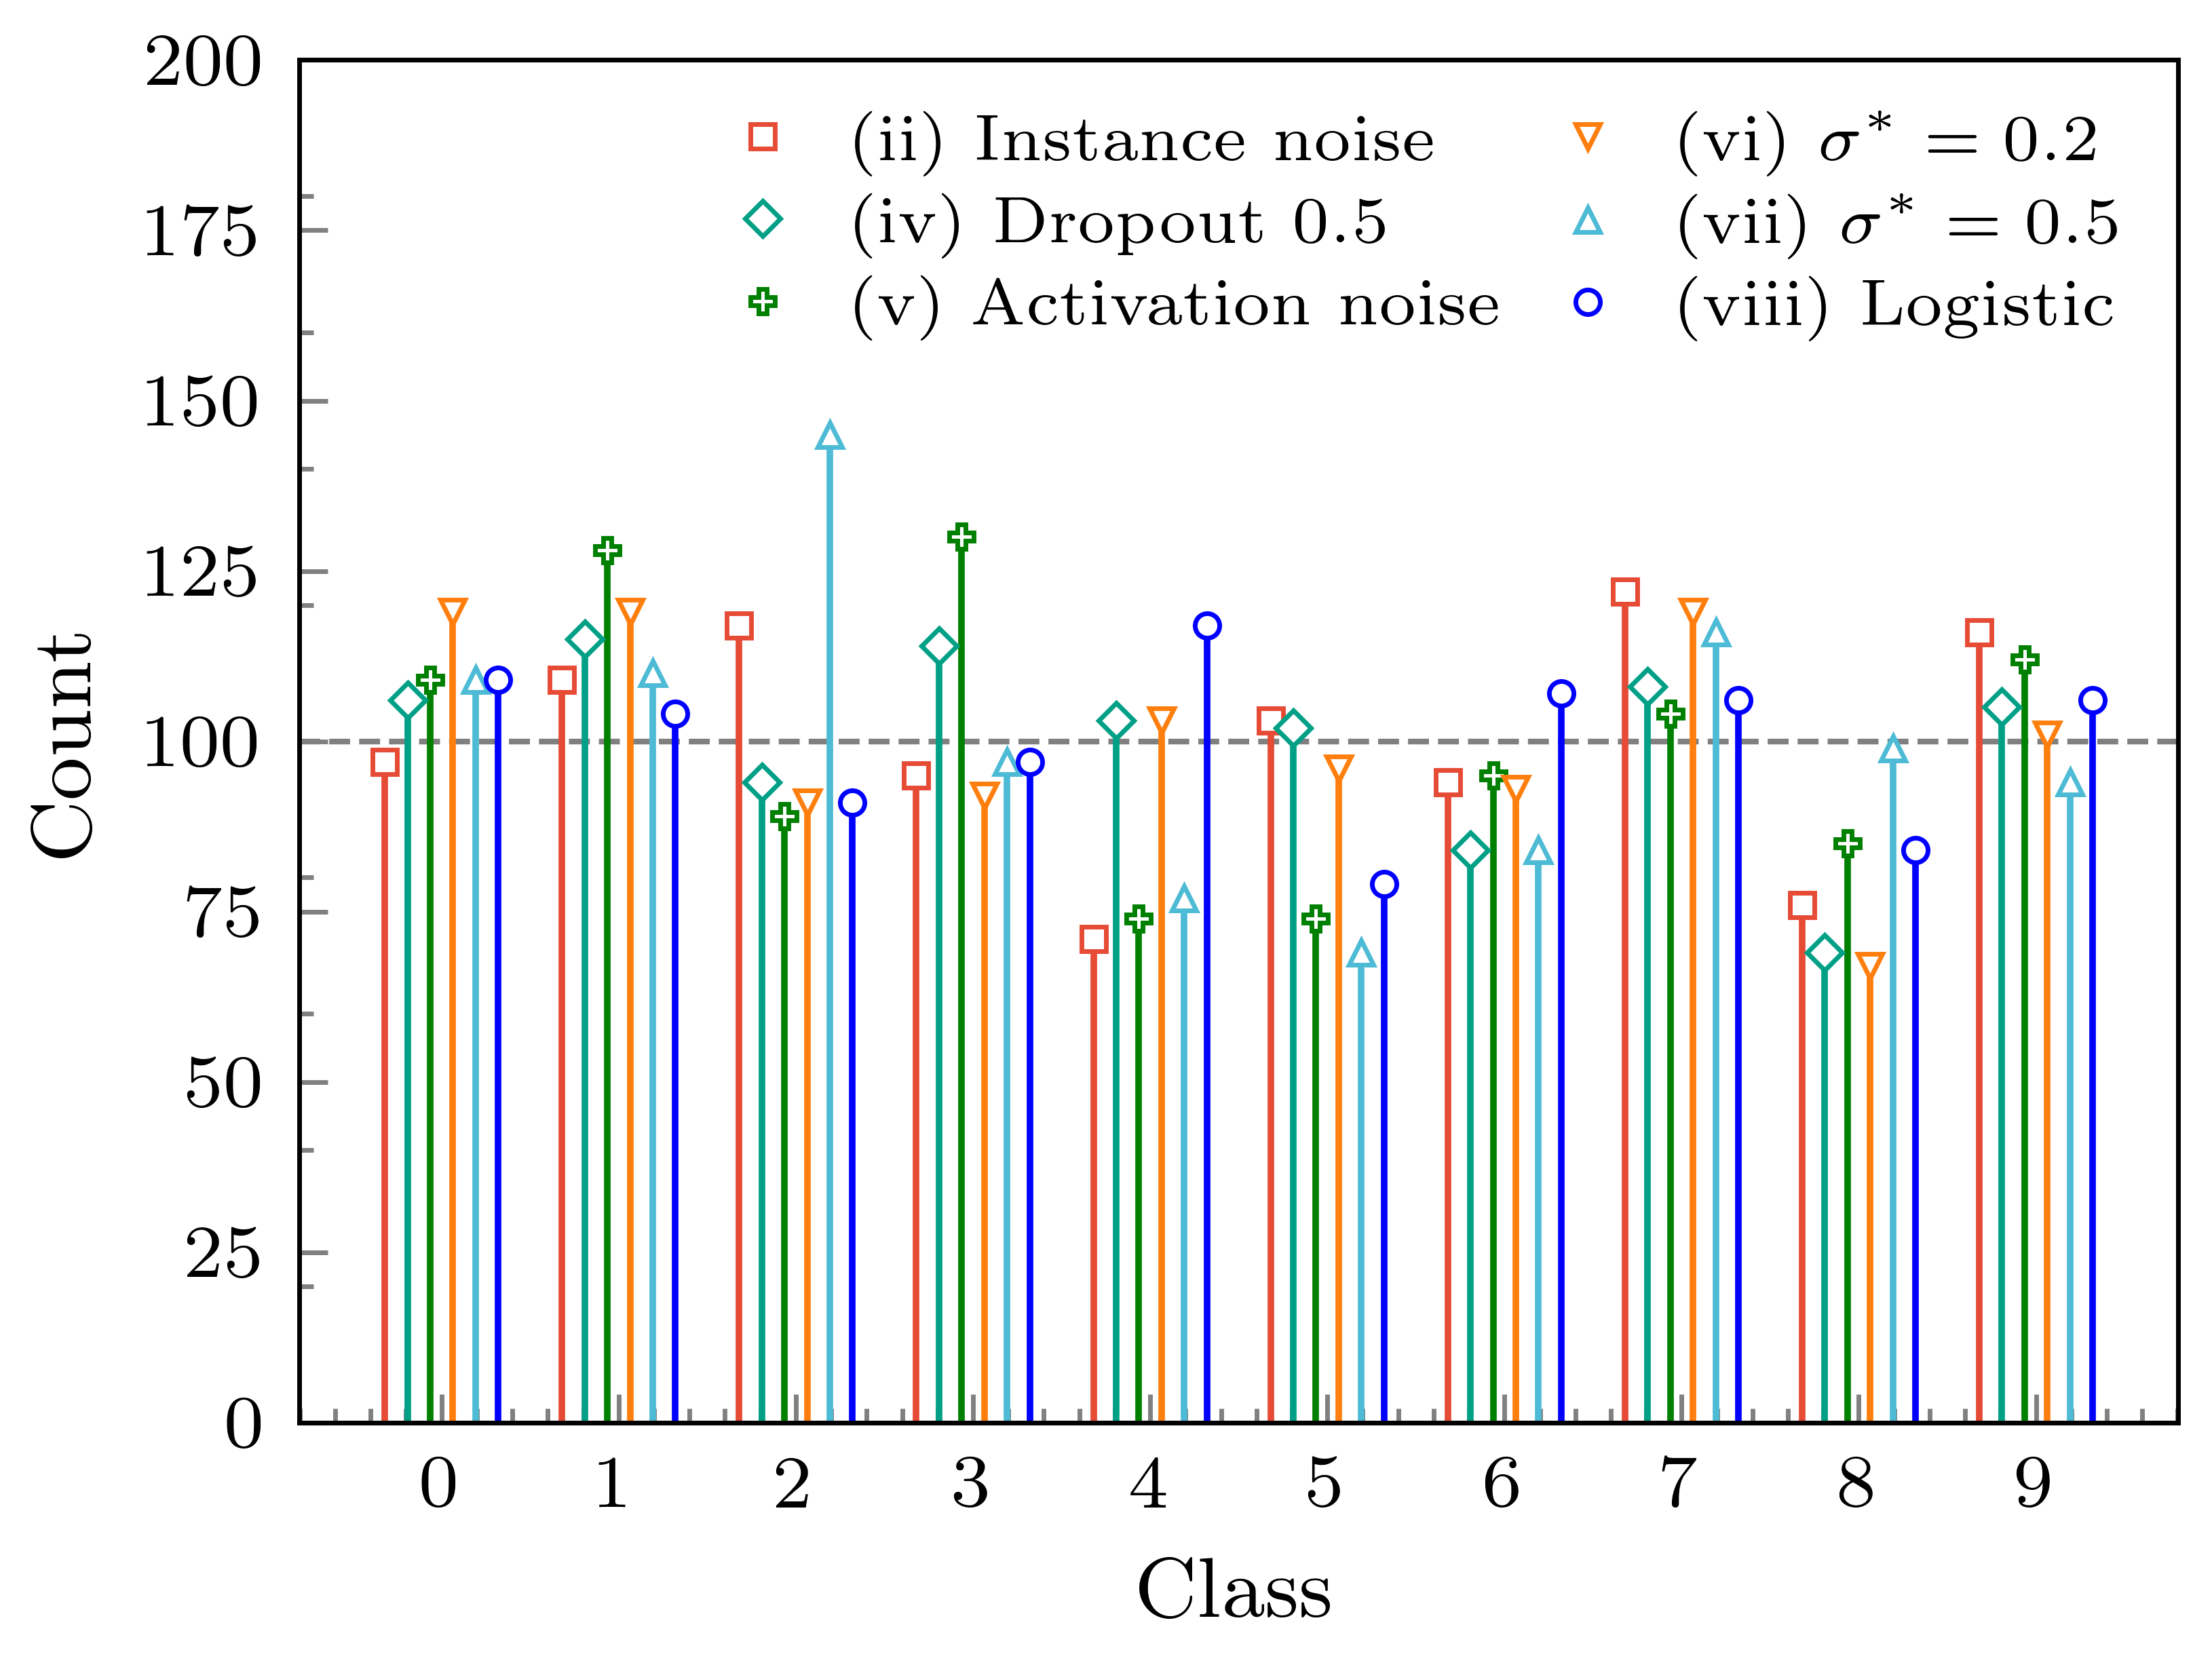

In [10]:
# =============================================================================
# FigAblationHist.eps  —  class-wise counts of 1000 generated digits
# 6 个避开 mode collapse 的变体 (sigmoid baseline 和 label smoothing 被省略)
# 风格与 Figcifarhist 完全一致; 在 JupyterLab 中直接运行此 cell 即可显示
# =============================================================================
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from matplotlib.ticker import MultipleLocator
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2025/resultsablation"

# 6 个成功变体; v8 (activation noise) 归入 sigmoid 组, 编号 (v),
# 原 logistic CDF 三项顺延为 (vi) / (vii) / (viii)
variants = {
    r"(ii) Instance noise":        f"{BASE}/v2_sigmoid_instance_noise/results.json",
    r"(iv) Dropout $0.5$":      f"{BASE}/v4_sigmoid_dropout05/results.json",
    r"(v) Activation noise":          f"{BASE}/v8_sigmoid_act_noise/results.json",
    r"(vi) $\sigma^\ast=0.2$":   f"{BASE}/v5_logistic_fixed_sigma0p2/results.json",
    r"(vii) $\sigma^\ast=0.5$":  f"{BASE}/v6_logistic_fixed_sigma0p5/results.json",
    r"(viii) Logistic":  f"{BASE}/v7_logistic_adaptive_sigma0p2/results.json",
}

def load_counts(path):
    r = json.load(open(path))
    cc = r["class_counts"]
    return np.array([cc.get(str(i), cc.get(i, 0)) for i in range(10)])

counts  = {lab: load_counts(p) for lab, p in variants.items()}
labels  = list(counts.keys())
colors  = ['#E64B35', '#00A087', 'g', '#FF7F0E', '#4DBBD5', 'b']
markers = ['s',       'D',       'P',       'v',       '^',       'o']
offsets = np.linspace(-0.32, 0.32, 6)

x = np.arange(10)
fig, ax = plt.subplots(figsize=(3.4, 2.6))

for lab, col, mk, off in zip(labels, colors, markers, offsets):
    c = counts[lab]
    ax.vlines(x + off, 0, c, colors=col, linewidth=0.7, zorder=2)
    ax.plot(x + off, c, linestyle='None', marker=mk, color=col,
            markersize=2.6,
            markerfacecolor='white',
            markeredgecolor=col,
            markeredgewidth=0.5,
            zorder=3,
            label=lab)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.6, zorder=1)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('k')

ax.set_xlabel('Class', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_xticks(x)
ax.tick_params(axis='x', which='both', top=False,   labelsize=8, width=0.5, color='gray')
ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(0, 200)
ax.legend(fontsize=7, loc='upper right', frameon=False,
          handlelength=1.2, labelspacing=0.25, borderpad=0.25,
          ncol=2, columnspacing=0.6)

plt.tight_layout()
plt.savefig('D:/PRE2025/FigAblationHist.eps', dpi=1000, bbox_inches='tight')
plt.show()

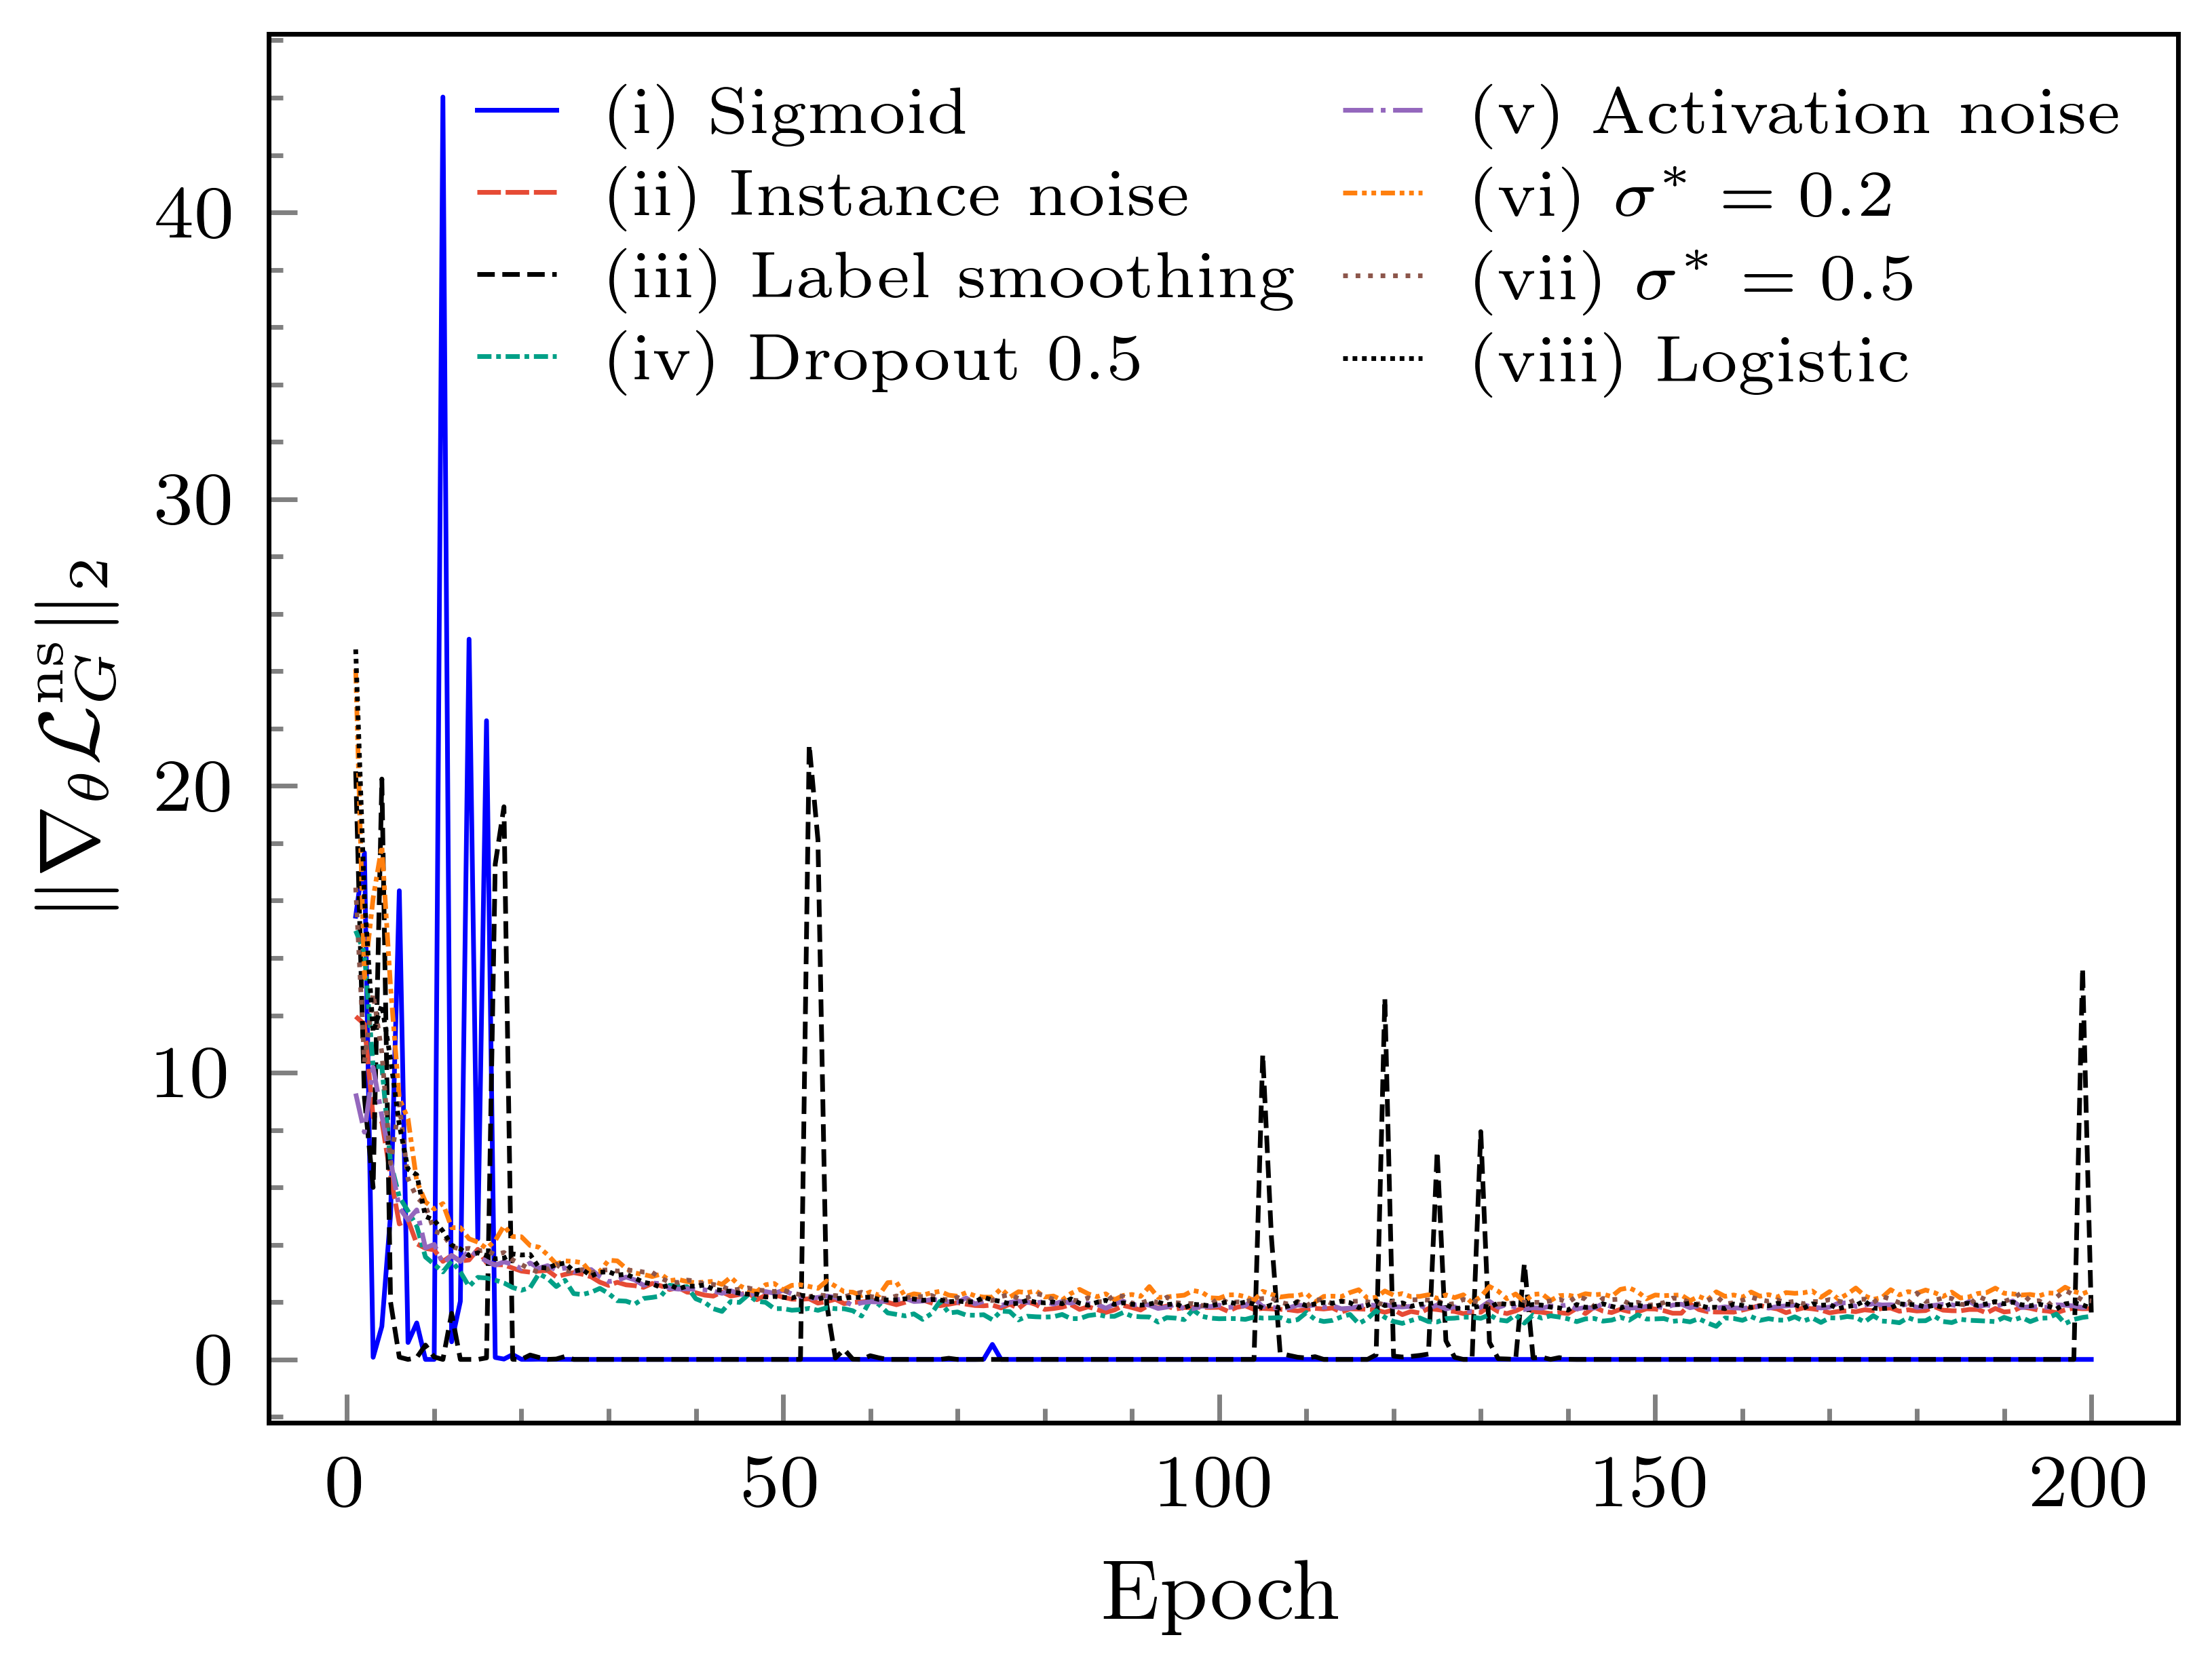

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2025/resultsablation"

variants = {
    r"(i) Sigmoid":                 f"{BASE}/v1_sigmoid/epoch_grad_norm.npy",
    r"(ii) Instance noise":          f"{BASE}/v2_sigmoid_instance_noise/epoch_grad_norm.npy",
    r"(iii) Label smoothing":        f"{BASE}/v3_sigmoid_label_smooth/epoch_grad_norm.npy",
    r"(iv) Dropout $0.5$":        f"{BASE}/v4_sigmoid_dropout05/epoch_grad_norm.npy",
    r"(v) Activation noise":            f"{BASE}/v8_sigmoid_act_noise/epoch_grad_norm.npy",
    r"(vi) $\sigma^\ast=0.2$":     f"{BASE}/v5_logistic_fixed_sigma0p2/epoch_grad_norm.npy",
    r"(vii) $\sigma^\ast=0.5$":    f"{BASE}/v6_logistic_fixed_sigma0p5/epoch_grad_norm.npy",
    r"(viii) Logistic":    f"{BASE}/v7_logistic_adaptive_sigma0p2/epoch_grad_norm.npy",
}

curves = {lab: np.sqrt(np.load(p)) for lab, p in variants.items()}
labels = list(curves.keys())

colors = ['b', '#E64B35', 'k', '#00A087',
          '#9467BD', '#FF7F0E', '#8C564B', 'k']

# 8 种互不相同的线型
linestyles = [
    '-',                              # (i)   solid
    (0, (5, 1)),                      # (ii)  densely dashed
    '--',                             # (iii) dashed
    (0, (3, 1, 1, 1)),                # (iv)  densely dashdotted
    '-.',                             # (v)   dashdot
    (0, (3, 1, 1, 1, 1, 1)),          # (vi)  densely dashdotdotted
    ':',                              # (vii) dotted
    (0, (1, 1)),                      # (viii) densely dotted
]

fig, ax = plt.subplots(figsize=(3.4, 2.6))
for lab, col, ls in zip(labels, colors, linestyles):
    y = curves[lab]
    x = np.arange(1, len(y) + 1)
    ax.plot(x, y, color=col, linestyle=ls, linewidth=0.5, label=lab)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('k')

ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel(r'$\|\nabla_\theta \mathcal{L}_G^{\mathrm{ns}}\|_2$', fontsize=9)
ax.tick_params(axis='x', which='both', top=False,   labelsize=8, width=0.5, color='gray')
ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')

ax.legend(fontsize=7, loc='upper right', frameon=False,
          handlelength=1.2,            # 线型更长一点，图例里才能看清 dash 模式
          labelspacing=0.25, borderpad=0.25,
          ncol=2, columnspacing=0.6)

plt.tight_layout()
plt.savefig('D:/PRE2025/FigAblation.eps', dpi=1000, bbox_inches='tight')
plt.show()